# MIMIC ED STAYS #

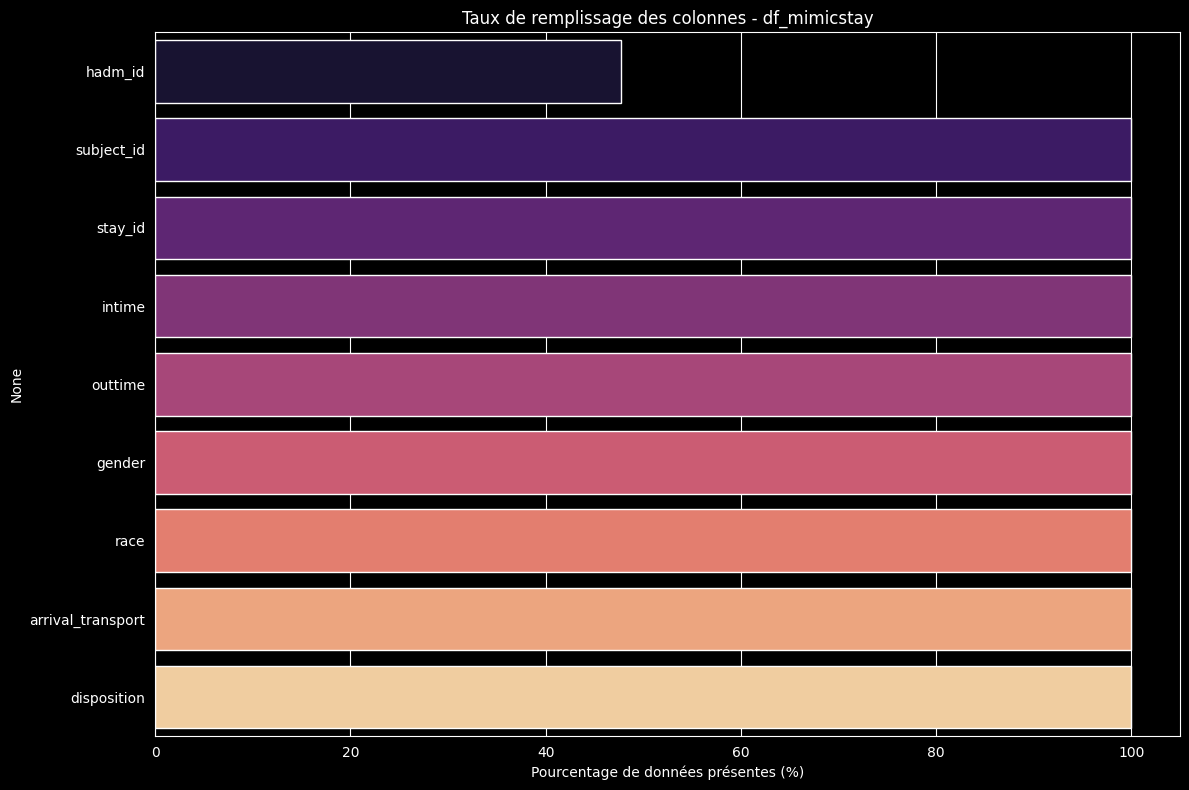

In [2]:
# Pandas détecte la compression .gz automatiquement
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement avec le nouveau nom
df_mimicstay = pd.read_csv('../share/mimic/mimic-iv-ed-2.2/ed/edstays.csv.gz')

# 2. Calcul du remplissage basé sur df_mimicstay
remplissage = (df_mimicstay.count() / len(df_mimicstay)) * 100
df_remplissage = remplissage.to_frame(name='Remplissage (%)').sort_values(by='Remplissage (%)')

# 3. Visualisation
plt.figure(figsize=(12, 8))
sns.barplot(x=df_remplissage['Remplissage (%)'], y=df_remplissage.index, palette='magma')

plt.title("Taux de remplissage des colonnes - df_mimicstay")
plt.xlabel("Pourcentage de données présentes (%)")
plt.tight_layout()
plt.show()

In [3]:
# 1. Lister les colonnes en excluant celles qui finissent par '_id'
cols_to_show = [c for c in df_mimicstay.columns if not c.endswith('_id')]

# 2. Afficher le type et un exemple de contenu pour chaque colonne
print(f"{'COLONNE':<20} | {'TYPE':<15} | {'EXEMPLE DE CONTENU'}")
print("-" * 60)

for col in cols_to_show:
    example = df_mimicstay[col].dropna().iloc[0] if not df_mimicstay[col].dropna().empty else "Vide"
    dtype = str(df_mimicstay[col].dtype)
    print(f"{col:<20} | {dtype:<15} | {example}")

COLONNE              | TYPE            | EXEMPLE DE CONTENU
------------------------------------------------------------
intime               | object          | 2180-05-06 19:17:00
outtime              | object          | 2180-05-06 23:30:00
gender               | object          | F
race                 | object          | WHITE
arrival_transport    | object          | AMBULANCE
disposition          | object          | ADMITTED


In [4]:
# Afficher les différentes catégories de la colonne 'disposition'
print("📊 RÉPARTITION DE LA VARIABLE 'DISPOSITION' :")
print(df_mimicstay['disposition'].value_counts(dropna=False))

# Si tu veux juste la liste unique des noms :
levels = df_mimicstay['disposition'].unique()
print("\nListe des niveaux :", levels)

📊 RÉPARTITION DE LA VARIABLE 'DISPOSITION' :
disposition
HOME                           241632
ADMITTED                       158010
TRANSFER                         7025
LEFT WITHOUT BEING SEEN          6155
ELOPED                           5710
OTHER                            4297
LEFT AGAINST MEDICAL ADVICE      1881
EXPIRED                           377
Name: count, dtype: int64

Liste des niveaux : ['ADMITTED' 'HOME' 'LEFT WITHOUT BEING SEEN' 'TRANSFER' 'ELOPED' 'OTHER'
 'LEFT AGAINST MEDICAL ADVICE' 'EXPIRED']


#

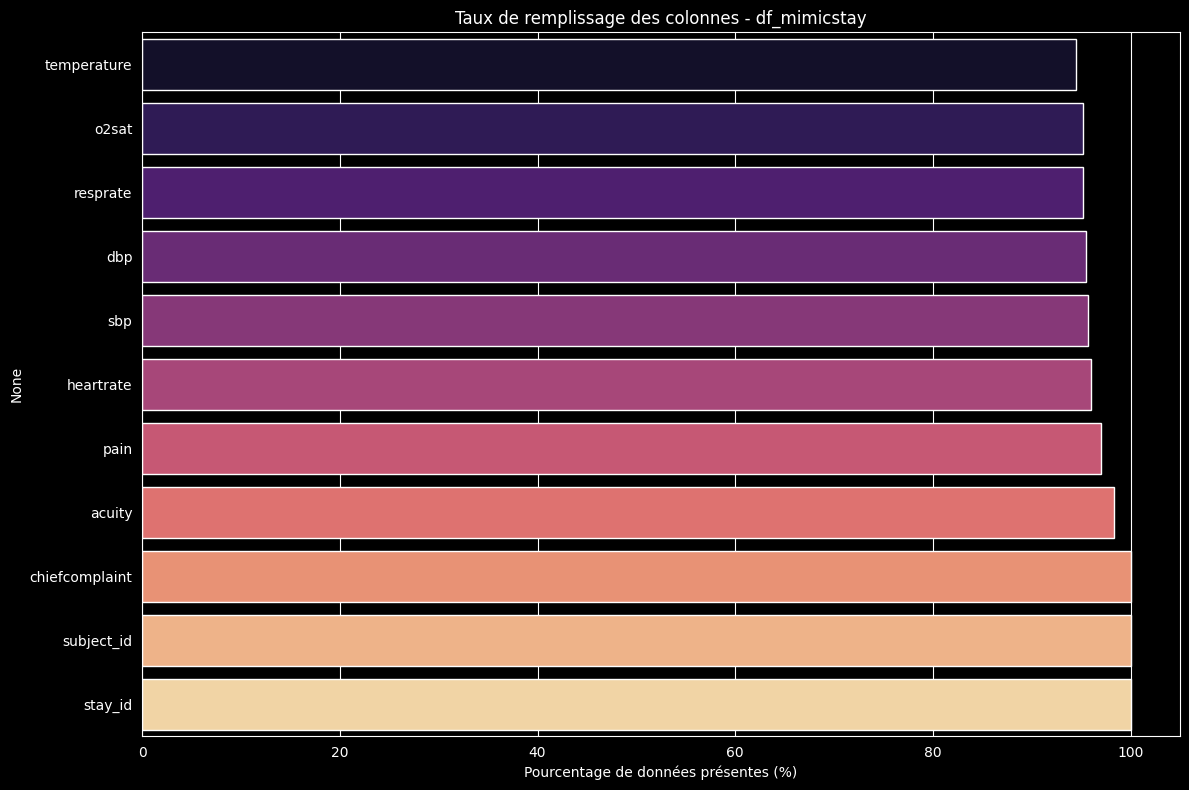

In [6]:
# 1. Chargement avec le nouveau nom
df_mimictriage = pd.read_csv('../share/mimic/mimic-iv-ed-2.2/ed/triage.csv.gz')

# 2. Calcul du remplissage basé sur df_mimicstay
remplissage = (df_mimictriage.count() / len(df_mimicstay)) * 100
df_remplissage = remplissage.to_frame(name='Remplissage (%)').sort_values(by='Remplissage (%)')

# 3. Visualisation
plt.figure(figsize=(12, 8))
sns.barplot(x=df_remplissage['Remplissage (%)'], y=df_remplissage.index, palette='magma')

plt.title("Taux de remplissage des colonnes - df_mimicstay")
plt.xlabel("Pourcentage de données présentes (%)")
plt.tight_layout()
plt.show()

In [8]:
# Afficher les différentes catégories de la colonne 'disposition'
print("📊 RÉPARTITION DE LA VARIABLE 'DISPOSITION' :")
print(df_mimictriage['chiefcomplaint'].value_counts(dropna=False))

# Si tu veux juste la liste unique des noms :
levels = df_mimictriage['chiefcomplaint'].unique()
print("\nListe des niveaux :", levels)

📊 RÉPARTITION DE LA VARIABLE 'DISPOSITION' :
chiefcomplaint
Chest pain                         11301
Abd pain                           10771
Dyspnea                             6003
s/p Fall                            4965
ABD PAIN                            4957
                                   ...  
Scrotal pain, Lower back pain          1
Abd pain, Diarrhea, Body pain          1
Weakness, Abnormal labs, Tremor        1
"I HAVE A STAPH INFECTION"             1
Headache, Fever, Syncope               1
Name: count, Length: 60407, dtype: int64

Liste des niveaux : ['Hypotension' 'Abd pain, Abdominal distention' 'n/v/d, Abd pain' ...
 'L CALF CELLULITIS' 'MVC/TRAUMA STAT' '? SEIZURE TODAY']


In [11]:
n_levels = df_mimictriage['chiefcomplaint'].nunique()
print(f"Il y a {n_levels} niveaux différents dans la colonne 'disposition'.")

Il y a 60406 niveaux différents dans la colonne 'disposition'.
